# Notebook 06 — GeoPandas Maps
## Climate-Responsive Social Protection: Geographic Visualisations

This notebook rebuilds the key choropleth maps from the CRSP project using **GeoPandas** instead of Plotly — providing more control over styling, projections, and layout.

### Maps produced
1. **Map 1** — CLVI World Choropleth (vulnerability scores)
2. **Map 2** — Protection Gap Map (where vulnerability exceeds provision)
3. **Map 3** — SP Coverage Map (social protection coverage rates)
4. **Map 4** — Data Invisibility Map (countries with no SP data highlighted)
5. **Map 5** — Red Zone Countries Map (countries at the crisis intersection)
6. **Map 6** — Side-by-side comparison panel

### Requirements
```
pip install geopandas matplotlib pandas numpy
```

The Natural Earth world shapefile is downloaded automatically on first run from:  
https://www.naturalearthdata.com/downloads/110m-cultural-vectors/

### Input
- `outputs/master_indexed.csv` — the merged master dataset with CLVI and protection gap scores

### Output
- All maps saved to `outputs/geopandas/`

---
## 0. Imports and Setup

In [ ]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
import os
import urllib.request
import zipfile

warnings.filterwarnings('ignore')

# ── Output folder ─────────────────────────────────────────────────────────────
os.makedirs('outputs/geopandas', exist_ok=True)

print('✓ Imports complete')

---
## 1. Load Data

In [20]:
# ── Load master dataset ───────────────────────────────────────────────────────
df = pd.read_csv(r"C:\Users\User\Documents\Iron Hack\FINAL PROJECT\climate-social-protection-analysis\outputs\master_indexed.csv")

print(f'Master dataset: {df.shape[0]} rows, {df.shape[1]} columns')
print(f'Key columns: {[c for c in df.columns if c in ["ISO3", "clvi", "sp_score", "protection_gap", "sp_coverage_rate", "income_group", "region_un"]]}')

Master dataset: 192 rows, 39 columns
Key columns: ['sp_coverage_rate', 'income_group', 'region_un', 'sp_score', 'protection_gap']


In [21]:
# ── Load Natural Earth 110m admin boundaries shapefile ────────────────────────
# Downloaded once and cached locally in data/raw/

shapefile_path = 'data/raw/ne_110m_admin_0_countries'

if not os.path.exists(shapefile_path):
    os.makedirs('data/raw', exist_ok=True)
    url = 'https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip'
    print('Downloading Natural Earth shapefile (one-time only)...')
    urllib.request.urlretrieve(url, 'data/raw/ne_110m.zip')
    with zipfile.ZipFile('data/raw/ne_110m.zip', 'r') as z:
        z.extractall(shapefile_path)
    print('✓ Downloaded and extracted')

world = gpd.read_file(shapefile_path)
print(f'✓ World shapefile loaded: {world.shape[0]} countries')
print(f'Available ISO columns: {[c for c in world.columns if "ISO" in c.upper() or "A3" in c.upper()]}')

✓ World shapefile loaded: 177 countries
Available ISO columns: ['SOV_A3', 'ADM0_A3', 'GU_A3', 'SU_A3', 'BRK_A3', 'ISO_A2', 'ISO_A2_EH', 'ISO_A3', 'ISO_A3_EH', 'ISO_N3', 'ISO_N3_EH', 'UN_A3', 'WB_A3', 'ADM0_ISO', 'ADM0_A3_US', 'ADM0_A3_FR', 'ADM0_A3_RU', 'ADM0_A3_ES', 'ADM0_A3_CN', 'ADM0_A3_TW', 'ADM0_A3_IN', 'ADM0_A3_NP', 'ADM0_A3_PK', 'ADM0_A3_DE', 'ADM0_A3_GB', 'ADM0_A3_BR', 'ADM0_A3_IL', 'ADM0_A3_PS', 'ADM0_A3_SA', 'ADM0_A3_EG', 'ADM0_A3_MA', 'ADM0_A3_PT', 'ADM0_A3_AR', 'ADM0_A3_JP', 'ADM0_A3_KO', 'ADM0_A3_VN', 'ADM0_A3_TR', 'ADM0_A3_ID', 'ADM0_A3_PL', 'ADM0_A3_GR', 'ADM0_A3_IT', 'ADM0_A3_NL', 'ADM0_A3_SE', 'ADM0_A3_BD', 'ADM0_A3_UA', 'ADM0_A3_UN', 'ADM0_A3_WB', 'FCLASS_ISO']


In [22]:
# ── Rename df columns to match world geometry ────────────────────────────────
# df uses lowercase iso3 and uppercase CLVI — standardise both
df = df.rename(columns={'iso3': 'ISO3', 'CLVI': 'clvi'})

# ── Reload shapefile and use ISO_A3 — best standard match ────────────────────
world2 = gpd.read_file(shapefile_path)
world2 = world2.rename(columns={'ISO_A3': 'ISO3'})

# Fix known -99 values in Natural Earth ISO_A3
iso_fixes = {
    'France':    'FRA',
    'Norway':    'NOR',
    'Kosovo':    'XKX',
    'N. Cyprus': 'CYP',
}
for name, iso in iso_fixes.items():
    world2.loc[world2['NAME'] == name, 'ISO3'] = iso

# ── Merge on ISO3 ─────────────────────────────────────────────────────────────
gdf = world2.merge(df, on='ISO3', how='left')

print(f'✓ Merged: {gdf.shape[0]} geometries')
print(f'Countries with CLVI data:  {gdf["clvi"].notna().sum()}')
print(f'Countries with SP data:    {gdf["sp_coverage_rate"].notna().sum()}')
print(f'Countries with NO SP data: {gdf["sp_coverage_rate"].isna().sum()}')

✓ Merged: 177 geometries
Countries with CLVI data:  165
Countries with SP data:    110
Countries with NO SP data: 67


---
## 2. Shared Styling

Colours and helper functions shared across all maps.

In [23]:
# ── Colour palette ─────────────────────────────────────────────────────────────
BACKGROUND = '#F5F0EB'   # warm off-white
OCEAN      = '#D6E8F0'   # light blue sea
NO_DATA    = '#CCCCCC'   # grey for missing data
BORDER     = '#FFFFFF'   # white country borders

# ── Source annotation ──────────────────────────────────────────────────────────
def add_source(ax, text='Source: ND-GAIN, WRI, ILO ILOSTAT, World Bank WDI | Analysis: Sarah El Jamal'):
    ax.annotate(
        text,
        xy=(0.01, 0.01), xycoords='figure fraction',
        fontsize=7, color='#888888', style='italic'
    )

# ── Country label helper ───────────────────────────────────────────────────────
def label_country(ax, gdf, iso, label, dx=3, dy=3, color='#1a1a1a',
                  fontsize=7.5, box_edge='#cccccc', box_color='white'):
    """Annotate a single country by ISO3 code with an arrow label."""
    row = gdf[gdf['ISO3'] == iso]
    if row.empty:
        return
    centroid = row.geometry.centroid.iloc[0]
    ax.annotate(
        label,
        xy=(centroid.x, centroid.y),
        xytext=(centroid.x + dx, centroid.y + dy),
        fontsize=fontsize, fontweight='bold', color=color,
        ha='center',
        bbox=dict(boxstyle='round,pad=0.25', facecolor=box_color, alpha=0.8, edgecolor=box_edge),
        arrowprops=dict(arrowstyle='->', color=color, lw=0.8)
    )

print('✓ Styling helpers defined')

✓ Styling helpers defined


---
## 3. Map 1 — CLVI World Choropleth

The Climate-Labor Vulnerability Index (CLVI) across 192 countries.  
Darker red = higher vulnerability. Grey = countries outside the ND-GAIN / WRI dataset.

**Key finding:** Vulnerability is concentrated in a belt across Sub-Saharan Africa, the Horn of Africa, South Asia, and parts of the Pacific — precisely the regions least responsible for historical emissions.

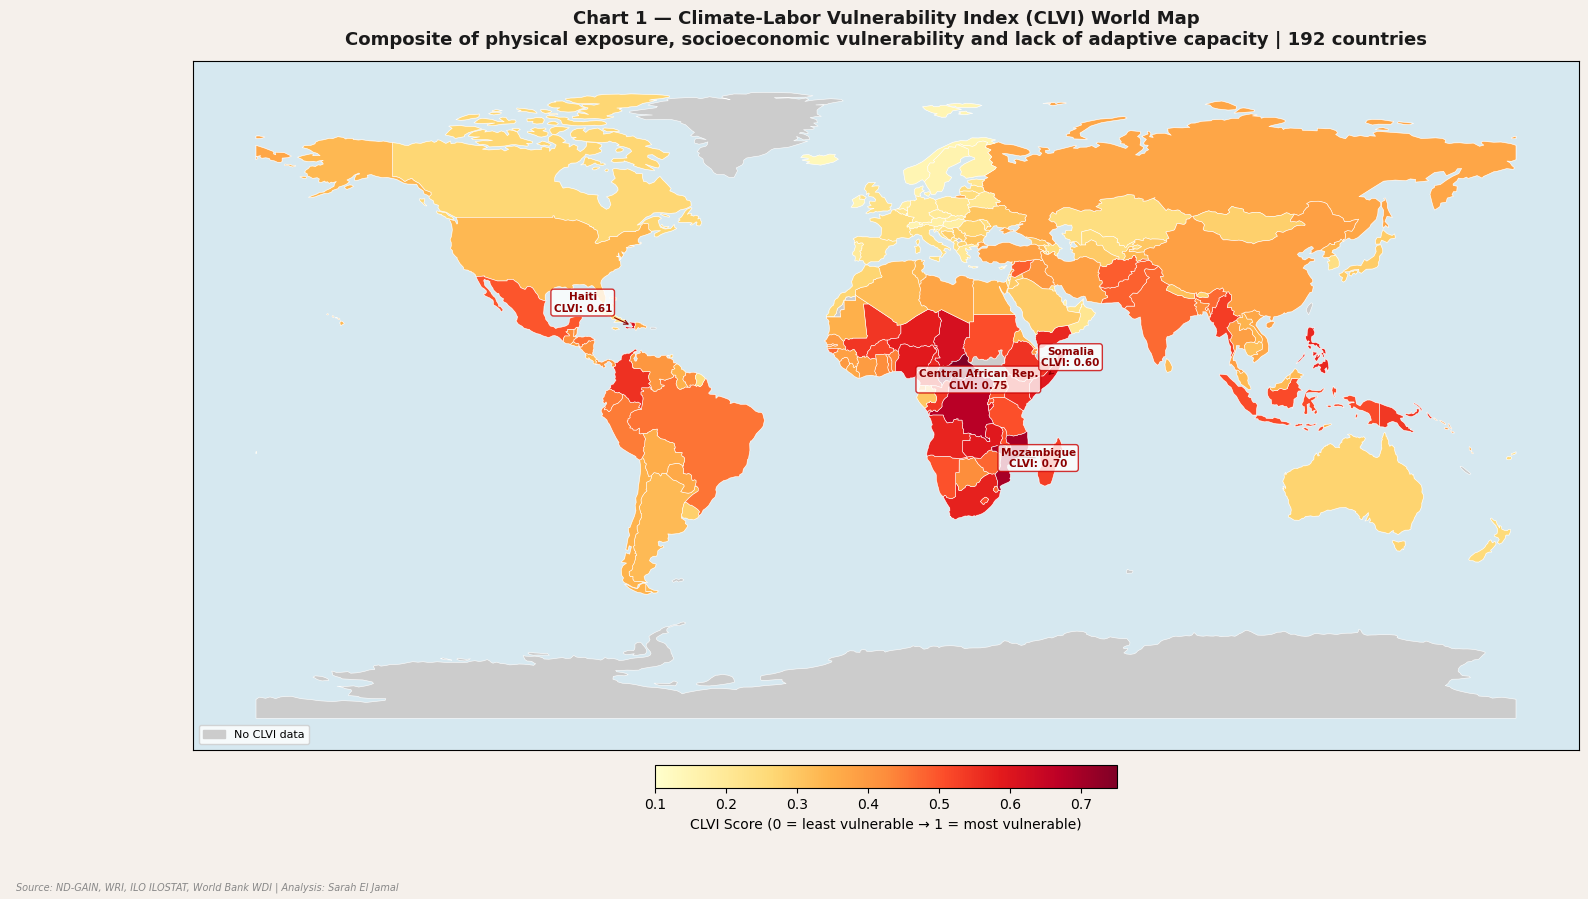

✓ Map 1 saved


In [24]:
fig, ax = plt.subplots(1, 1, figsize=(16, 9))
fig.patch.set_facecolor(BACKGROUND)
ax.set_facecolor(OCEAN)

# ── Base: all countries (catches those with no CLVI data) ─────────────────────
gdf.plot(ax=ax, color=NO_DATA, edgecolor=BORDER, linewidth=0.4)

# ── Choropleth: CLVI score ────────────────────────────────────────────────────
gdf[gdf['clvi'].notna()].plot(
    column='clvi',
    ax=ax,
    cmap='YlOrRd',
    vmin=0.1, vmax=0.75,
    edgecolor=BORDER,
    linewidth=0.4,
    legend=True,
    legend_kwds={
        'label': 'CLVI Score (0 = least vulnerable → 1 = most vulnerable)',
        'orientation': 'horizontal',
        'fraction': 0.03, 'pad': 0.02, 'shrink': 0.6
    }
)

# ── Annotate four case study countries ────────────────────────────────────────
case_labels = {
    'CAF': ('Central African Rep.\nCLVI: 0.75',  6,  -5, '#8B0000'),
    'MOZ': ('Mozambique\nCLVI: 0.70',            8,  -3, '#8B0000'),
    'SOM': ('Somalia\nCLVI: 0.60',               7,   3, '#8B0000'),
    'HTI': ('Haiti\nCLVI: 0.61',               -14,   4, '#8B0000'),
}
for iso, (lbl, dx, dy, col) in case_labels.items():
    label_country(ax, gdf, iso, lbl, dx=dx, dy=dy, color=col, box_edge='#cc0000')

ax.set_title(
    'Chart 1 — Climate-Labor Vulnerability Index (CLVI) World Map\n'
    'Composite of physical exposure, socioeconomic vulnerability and lack of adaptive capacity | 192 countries',
    fontsize=13, fontweight='bold', color='#1a1a1a', pad=12
)
ax.set_xticks([])
ax.set_yticks([])

no_data_patch = mpatches.Patch(color=NO_DATA, label='No CLVI data')
ax.legend(handles=[no_data_patch], loc='lower left', fontsize=8, framealpha=0.8)

add_source(ax)
plt.tight_layout()
plt.savefig('outputs/geopandas/map1_clvi_geopandas.png', dpi=150, bbox_inches='tight', facecolor=BACKGROUND)
plt.show()
print('✓ Map 1 saved')

---
## 4. Map 2 — Protection Gap Map

Protection Gap Score = CLVI − normalised SP coverage rate.  
**Red** = vulnerability exceeds protection (unmet need).  
**Green** = protection exceeds vulnerability (well insured).

**Key finding:** The global SP system is well-designed for the people who need it least, and absent for those who need it most — a near-perfect geographic inversion.

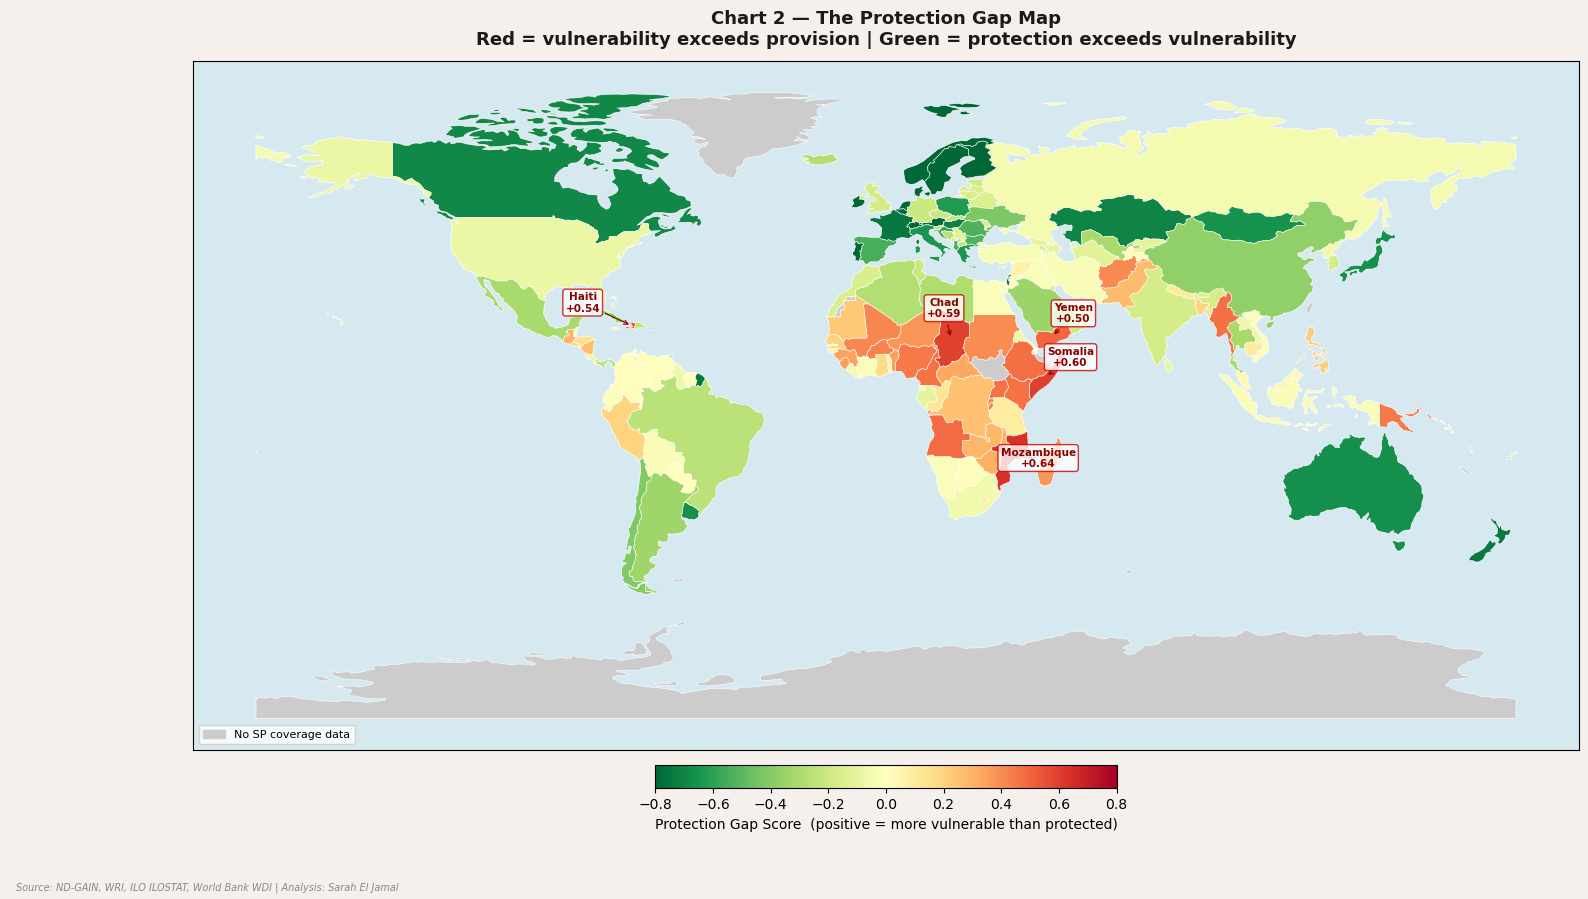

✓ Map 2 saved


In [25]:
fig, ax = plt.subplots(1, 1, figsize=(16, 9))
fig.patch.set_facecolor(BACKGROUND)
ax.set_facecolor(OCEAN)

gdf.plot(ax=ax, color=NO_DATA, edgecolor=BORDER, linewidth=0.4)

gdf[gdf['protection_gap'].notna()].plot(
    column='protection_gap',
    ax=ax,
    cmap='RdYlGn_r',
    vmin=-0.8, vmax=0.8,
    edgecolor=BORDER,
    linewidth=0.4,
    legend=True,
    legend_kwds={
        'label': 'Protection Gap Score  (positive = more vulnerable than protected)',
        'orientation': 'horizontal',
        'fraction': 0.03, 'pad': 0.02, 'shrink': 0.6
    }
)

# ── Annotate top 5 Red Zone countries ─────────────────────────────────────────
top5 = {
    'MOZ': ('Mozambique',  8,  -3),
    'SOM': ('Somalia',     7,   3),
    'TCD': ('Chad',       -2,   6),
    'HTI': ('Haiti',     -14,   4),
    'YEM': ('Yemen',       6,   4),
}
for iso, (name, dx, dy) in top5.items():
    row = gdf[gdf['ISO3'] == iso]
    if row.empty or row['protection_gap'].isna().all():
        continue
    gap = row['protection_gap'].iloc[0]
    label_country(ax, gdf, iso, f'{name}\n+{gap:.2f}', dx=dx, dy=dy,
                  color='#8B0000', box_edge='#cc0000')

ax.set_title(
    'Chart 2 — The Protection Gap Map\n'
    'Red = vulnerability exceeds provision | Green = protection exceeds vulnerability',
    fontsize=13, fontweight='bold', color='#1a1a1a', pad=12
)
ax.set_xticks([])
ax.set_yticks([])

no_data_patch = mpatches.Patch(color=NO_DATA, label='No SP coverage data')
ax.legend(handles=[no_data_patch], loc='lower left', fontsize=8, framealpha=0.8)

add_source(ax)
plt.tight_layout()
plt.savefig('outputs/geopandas/map2_protection_gap_geopandas.png', dpi=150, bbox_inches='tight', facecolor=BACKGROUND)
plt.show()
print('✓ Map 2 saved')

---
## 5. Map 3 — SP Coverage Map

Social protection coverage rate by country (ILO SDG 1.3.1).  
Darker green = higher coverage. Grey = no data available (41% of countries).

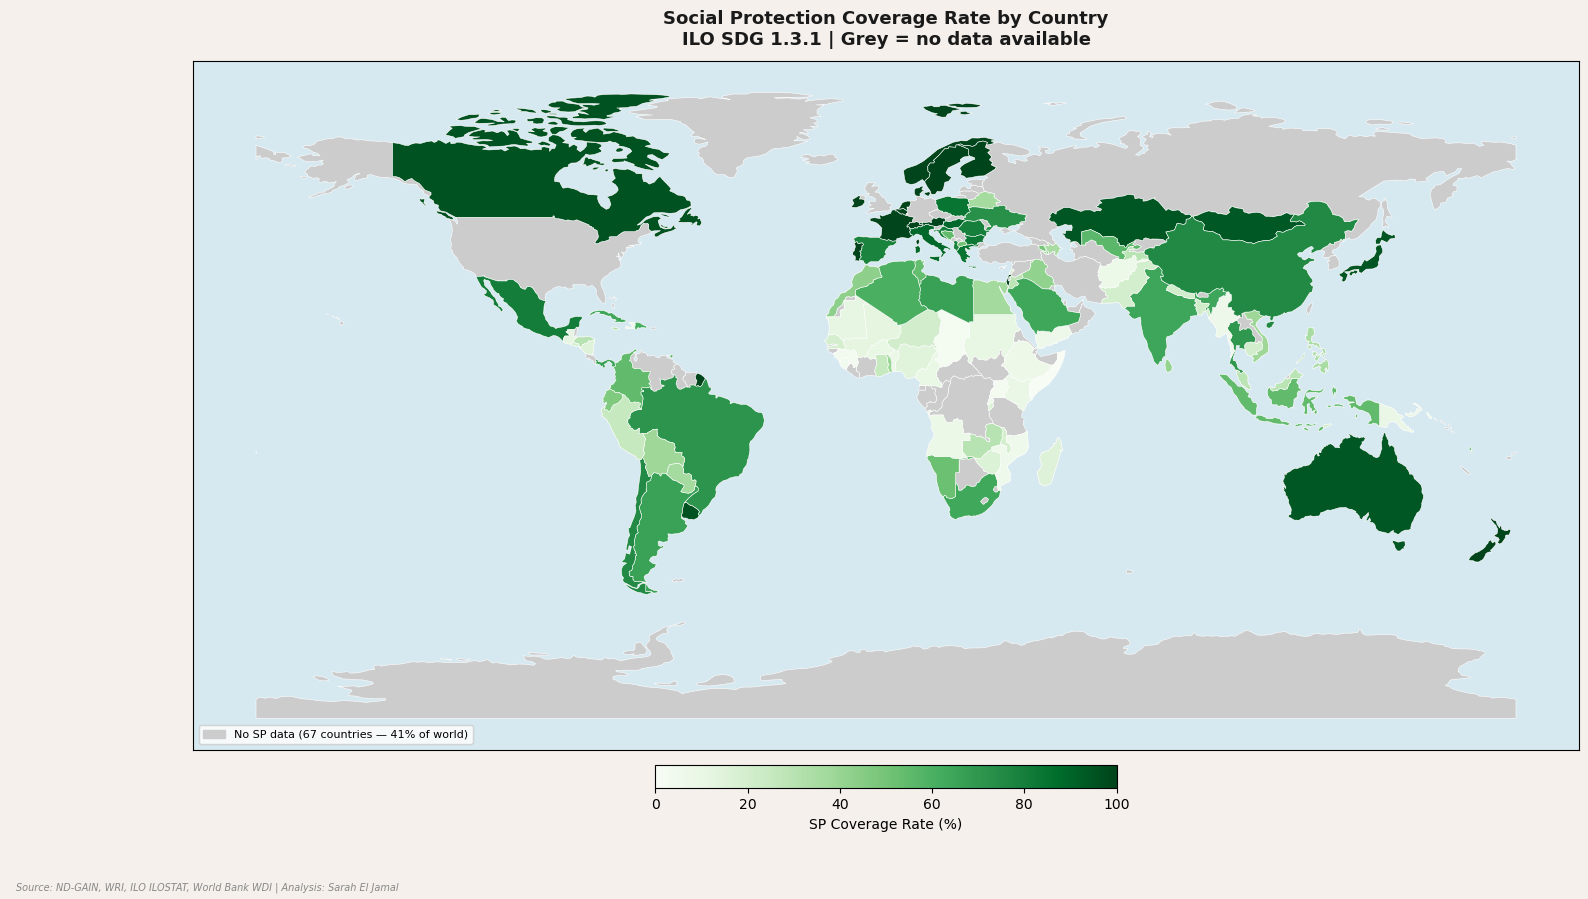

✓ Map 3 saved


In [26]:
fig, ax = plt.subplots(1, 1, figsize=(16, 9))
fig.patch.set_facecolor(BACKGROUND)
ax.set_facecolor(OCEAN)

gdf.plot(ax=ax, color=NO_DATA, edgecolor=BORDER, linewidth=0.4)

gdf[gdf['sp_coverage_rate'].notna()].plot(
    column='sp_coverage_rate',
    ax=ax,
    cmap='Greens',
    vmin=0, vmax=100,
    edgecolor=BORDER,
    linewidth=0.4,
    legend=True,
    legend_kwds={
        'label': 'SP Coverage Rate (%)',
        'orientation': 'horizontal',
        'fraction': 0.03, 'pad': 0.02, 'shrink': 0.6
    }
)

ax.set_title(
    'Social Protection Coverage Rate by Country\n'
    'ILO SDG 1.3.1 | Grey = no data available',
    fontsize=13, fontweight='bold', color='#1a1a1a', pad=12
)
ax.set_xticks([])
ax.set_yticks([])

n_no_data = gdf['sp_coverage_rate'].isna().sum()
no_data_patch = mpatches.Patch(color=NO_DATA, label=f'No SP data ({n_no_data} countries — 41% of world)')
ax.legend(handles=[no_data_patch], loc='lower left', fontsize=8, framealpha=0.8)

add_source(ax)
plt.tight_layout()
plt.savefig('outputs/geopandas/map3_sp_coverage_geopandas.png', dpi=150, bbox_inches='tight', facecolor=BACKGROUND)
plt.show()
print('✓ Map 3 saved')

---
## 6. Map 4 — Data Invisibility Map

**H5 Finding:** 79 countries — 41% of the world — have no SP coverage data in the ILO's SDG 1.3.1 monitoring framework.

This map makes the invisible visible. Countries with no SP data are shaded by their CLVI score where available, showing the cost of that invisibility: the countries most urgently needing attention are the ones the global monitoring architecture cannot see.

The Central African Republic — the single most vulnerable country in the entire dataset (CLVI: 0.748) — has no SP data whatsoever. The country the system most needs to monitor is invisible to it.

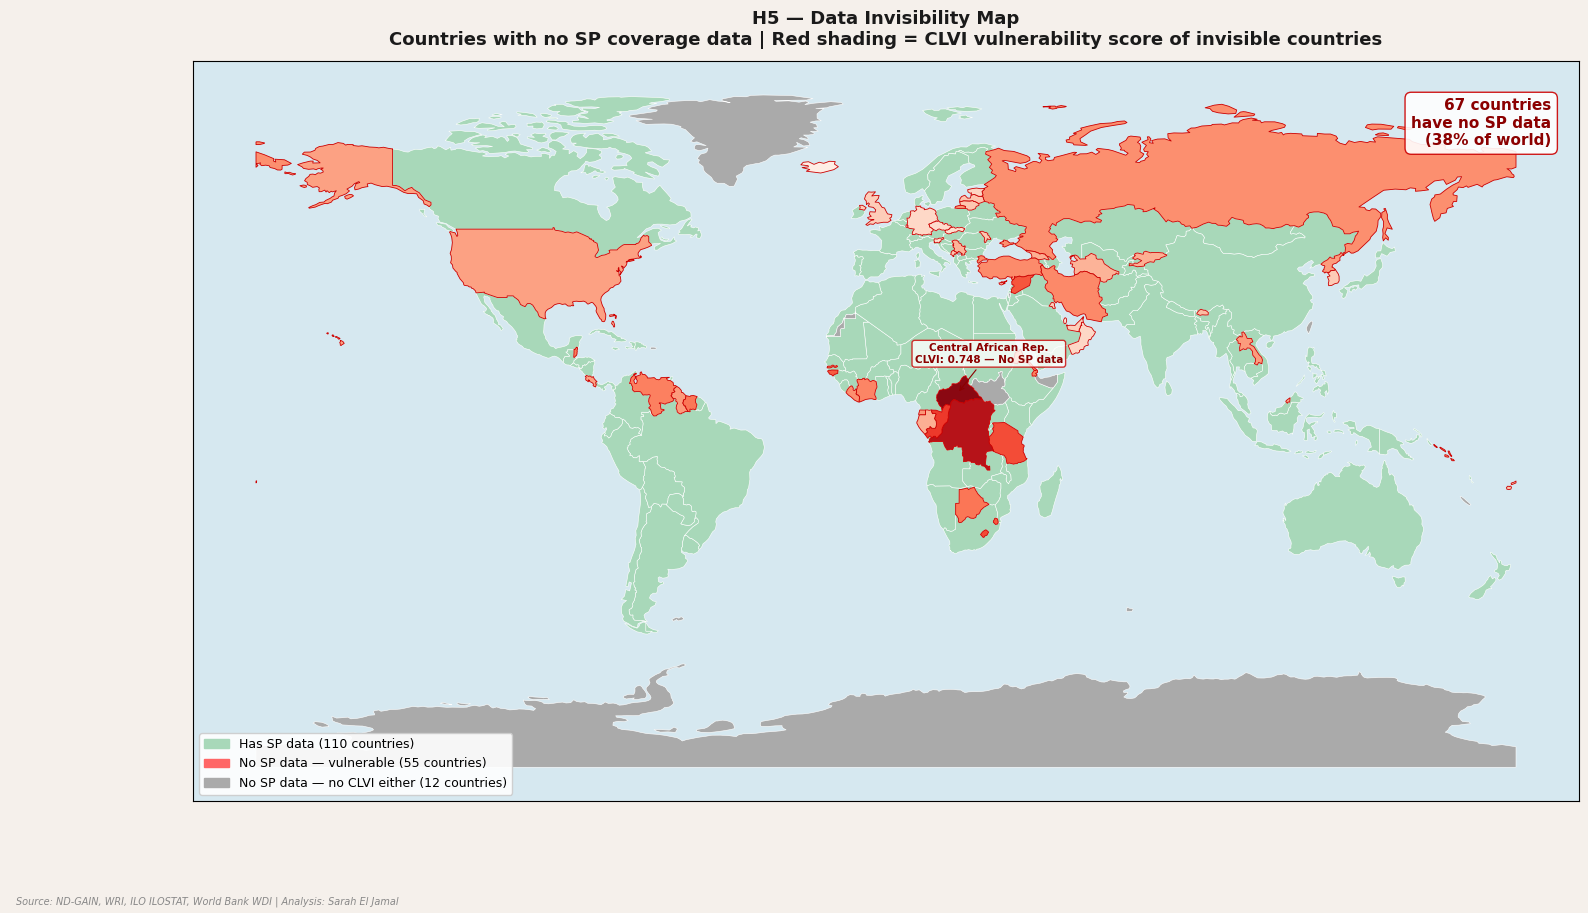

✓ Map 4 saved


In [27]:
fig, ax = plt.subplots(1, 1, figsize=(16, 9))
fig.patch.set_facecolor(BACKGROUND)
ax.set_facecolor(OCEAN)

# ── Layer 1: countries WITH SP data ───────────────────────────────────────────
has_data = gdf[gdf['sp_coverage_rate'].notna()]
has_data.plot(ax=ax, color='#A8D8B9', edgecolor=BORDER, linewidth=0.4)

# ── Layer 2: countries WITHOUT SP data ────────────────────────────────────────
no_sp = gdf[gdf['sp_coverage_rate'].isna()]

# No SP data and no CLVI — truly unknown
no_sp[no_sp['clvi'].isna()].plot(
    ax=ax, color='#AAAAAA', edgecolor=BORDER, linewidth=0.4
)

# No SP data but CLVI available — invisible but measurably vulnerable
no_sp[no_sp['clvi'].notna()].plot(
    column='clvi',
    ax=ax,
    cmap='Reds',
    vmin=0.1, vmax=0.8,
    edgecolor='#cc0000',
    linewidth=0.6
)

ax.set_title(
    'H5 — Data Invisibility Map\n'
    'Countries with no SP coverage data | Red shading = CLVI vulnerability score of invisible countries',
    fontsize=13, fontweight='bold', color='#1a1a1a', pad=12
)
ax.set_xticks([])
ax.set_yticks([])

# ── Annotate CAR — most vulnerable invisible country ──────────────────────────
label_country(
    ax, gdf, 'CAF',
    'Central African Rep.\nCLVI: 0.748 — No SP data',
    dx=9, dy=8, color='#8B0000', box_edge='#cc0000'
)

# ── Legend ─────────────────────────────────────────────────────────────────────
n_invisible  = len(no_sp)
n_has        = len(has_data)
n_vuln_inv   = no_sp['clvi'].notna().sum()
n_total_unk  = no_sp['clvi'].isna().sum()

p_has  = mpatches.Patch(color='#A8D8B9', label=f'Has SP data ({n_has} countries)')
p_inv  = mpatches.Patch(color='#FF6666', label=f'No SP data — vulnerable ({n_vuln_inv} countries)')
p_unk  = mpatches.Patch(color='#AAAAAA', label=f'No SP data — no CLVI either ({n_total_unk} countries)')
ax.legend(handles=[p_has, p_inv, p_unk], loc='lower left', fontsize=9, framealpha=0.9)

# ── Summary count ──────────────────────────────────────────────────────────────
ax.text(
    0.98, 0.95,
    f'{n_invisible} countries\nhave no SP data\n({n_invisible / len(gdf) * 100:.0f}% of world)',
    transform=ax.transAxes,
    fontsize=11, fontweight='bold', color='#8B0000',
    ha='right', va='top',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.9, edgecolor='#cc0000')
)

add_source(ax)
plt.tight_layout()
plt.savefig('outputs/geopandas/map4_invisibility_geopandas.png', dpi=150, bbox_inches='tight', facecolor=BACKGROUND)
plt.show()
print('✓ Map 4 saved')

---
## 7. Map 5 — Red Zone Countries

The Red Zone: countries with above-median climate exposure AND below-median SP coverage.  
All other countries are greyed out to focus attention on the Red Zone cluster.

**Key finding:** The Red Zone is not a set of random outliers — it is a systematic geographic cluster concentrated in Sub-Saharan Africa, the Arab world, and the Caribbean.

In [28]:
# ── Identify Red Zone countries ────────────────────────────────────────────────
clvi_median = df['clvi'].median()
sp_median   = df['sp_coverage_rate'].median()

red_zone_iso = df[
    (df['clvi'] > clvi_median) &
    (df['sp_coverage_rate'].notna()) &
    (df['sp_coverage_rate'] < sp_median)
]['ISO3'].tolist()

gdf['red_zone'] = gdf['ISO3'].isin(red_zone_iso)

print(f'Red Zone countries identified: {len(red_zone_iso)}')
print(sorted(red_zone_iso))

Red Zone countries identified: 47
['AFG', 'AGO', 'BDI', 'BEN', 'BFA', 'BGD', 'BOL', 'CMR', 'EGY', 'ETH', 'GHA', 'GIN', 'GTM', 'HND', 'HTI', 'KEN', 'LBN', 'MDG', 'MLI', 'MMR', 'MOZ', 'MRT', 'MWI', 'MYS', 'NER', 'NGA', 'NIC', 'PAK', 'PER', 'PHL', 'PNG', 'PRY', 'RWA', 'SDN', 'SEN', 'SLE', 'SLV', 'SOM', 'TCD', 'TGO', 'TJK', 'TLS', 'UGA', 'VNM', 'YEM', 'ZMB', 'ZWE']


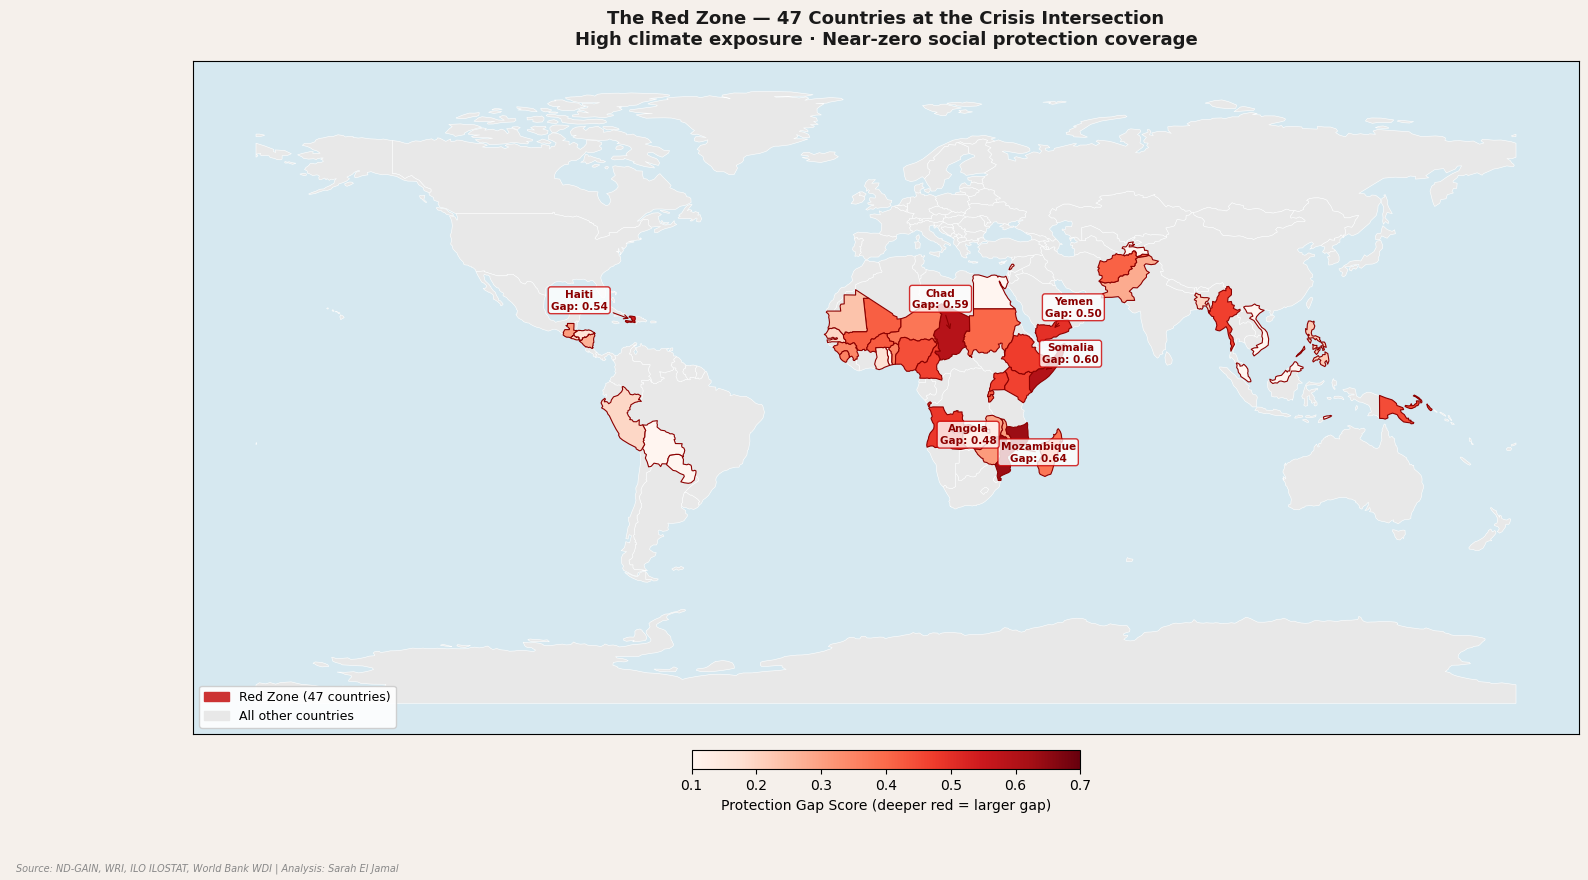

✓ Map 5 saved


In [29]:
fig, ax = plt.subplots(1, 1, figsize=(16, 9))
fig.patch.set_facecolor(BACKGROUND)
ax.set_facecolor(OCEAN)

# ── All non-Red Zone countries — muted grey ────────────────────────────────────
gdf[~gdf['red_zone']].plot(ax=ax, color='#E8E8E8', edgecolor=BORDER, linewidth=0.4)

# ── Red Zone countries — coloured by protection gap ───────────────────────────
gdf[gdf['red_zone']].plot(
    column='protection_gap',
    ax=ax,
    cmap='Reds',
    vmin=0.1, vmax=0.7,
    edgecolor='#8B0000',
    linewidth=0.8,
    legend=True,
    legend_kwds={
        'label': 'Protection Gap Score (deeper red = larger gap)',
        'orientation': 'horizontal',
        'fraction': 0.025, 'pad': 0.02, 'shrink': 0.5
    }
)

# ── Annotate top 6 Red Zone countries ─────────────────────────────────────────
top_red = (
    df[df['ISO3'].isin(red_zone_iso)]
    .nlargest(6, 'protection_gap')[['ISO3', 'protection_gap']]
)
label_offsets = {
    'MOZ': (8, -4), 'SOM': (7, 2), 'TCD': (-3, 7),
    'HTI': (-15, 3), 'YEM': (6, 4), 'AGO': (6, -4)
}
for _, row_data in top_red.iterrows():
    iso = row_data['ISO3']
    gap = row_data['protection_gap']
    row = gdf[gdf['ISO3'] == iso]
    if row.empty:
        continue
    name = row['NAME'].iloc[0]
    dx, dy = label_offsets.get(iso, (4, 4))
    label_country(ax, gdf, iso, f'{name}\nGap: {gap:.2f}',
                  dx=dx, dy=dy, color='#8B0000', box_edge='#cc0000')

ax.set_title(
    f'The Red Zone — {len(red_zone_iso)} Countries at the Crisis Intersection\n'
    'High climate exposure · Near-zero social protection coverage',
    fontsize=13, fontweight='bold', color='#1a1a1a', pad=12
)
ax.set_xticks([])
ax.set_yticks([])

red_patch   = mpatches.Patch(color='#CC3333', label=f'Red Zone ({len(red_zone_iso)} countries)')
other_patch = mpatches.Patch(color='#E8E8E8', label='All other countries')
ax.legend(handles=[red_patch, other_patch], loc='lower left', fontsize=9, framealpha=0.9)

add_source(ax)
plt.tight_layout()
plt.savefig('outputs/geopandas/map5_redzone_geopandas.png', dpi=150, bbox_inches='tight', facecolor=BACKGROUND)
plt.show()
print('✓ Map 5 saved')

---
## 8. Map 6 — Side-by-Side Panel

CLVI (top) and Protection Gap (bottom) displayed together.  
The central visual argument of the project: the two maps are near-perfect mirror images.  
Countries darkest on vulnerability are palest on coverage — and vice versa.

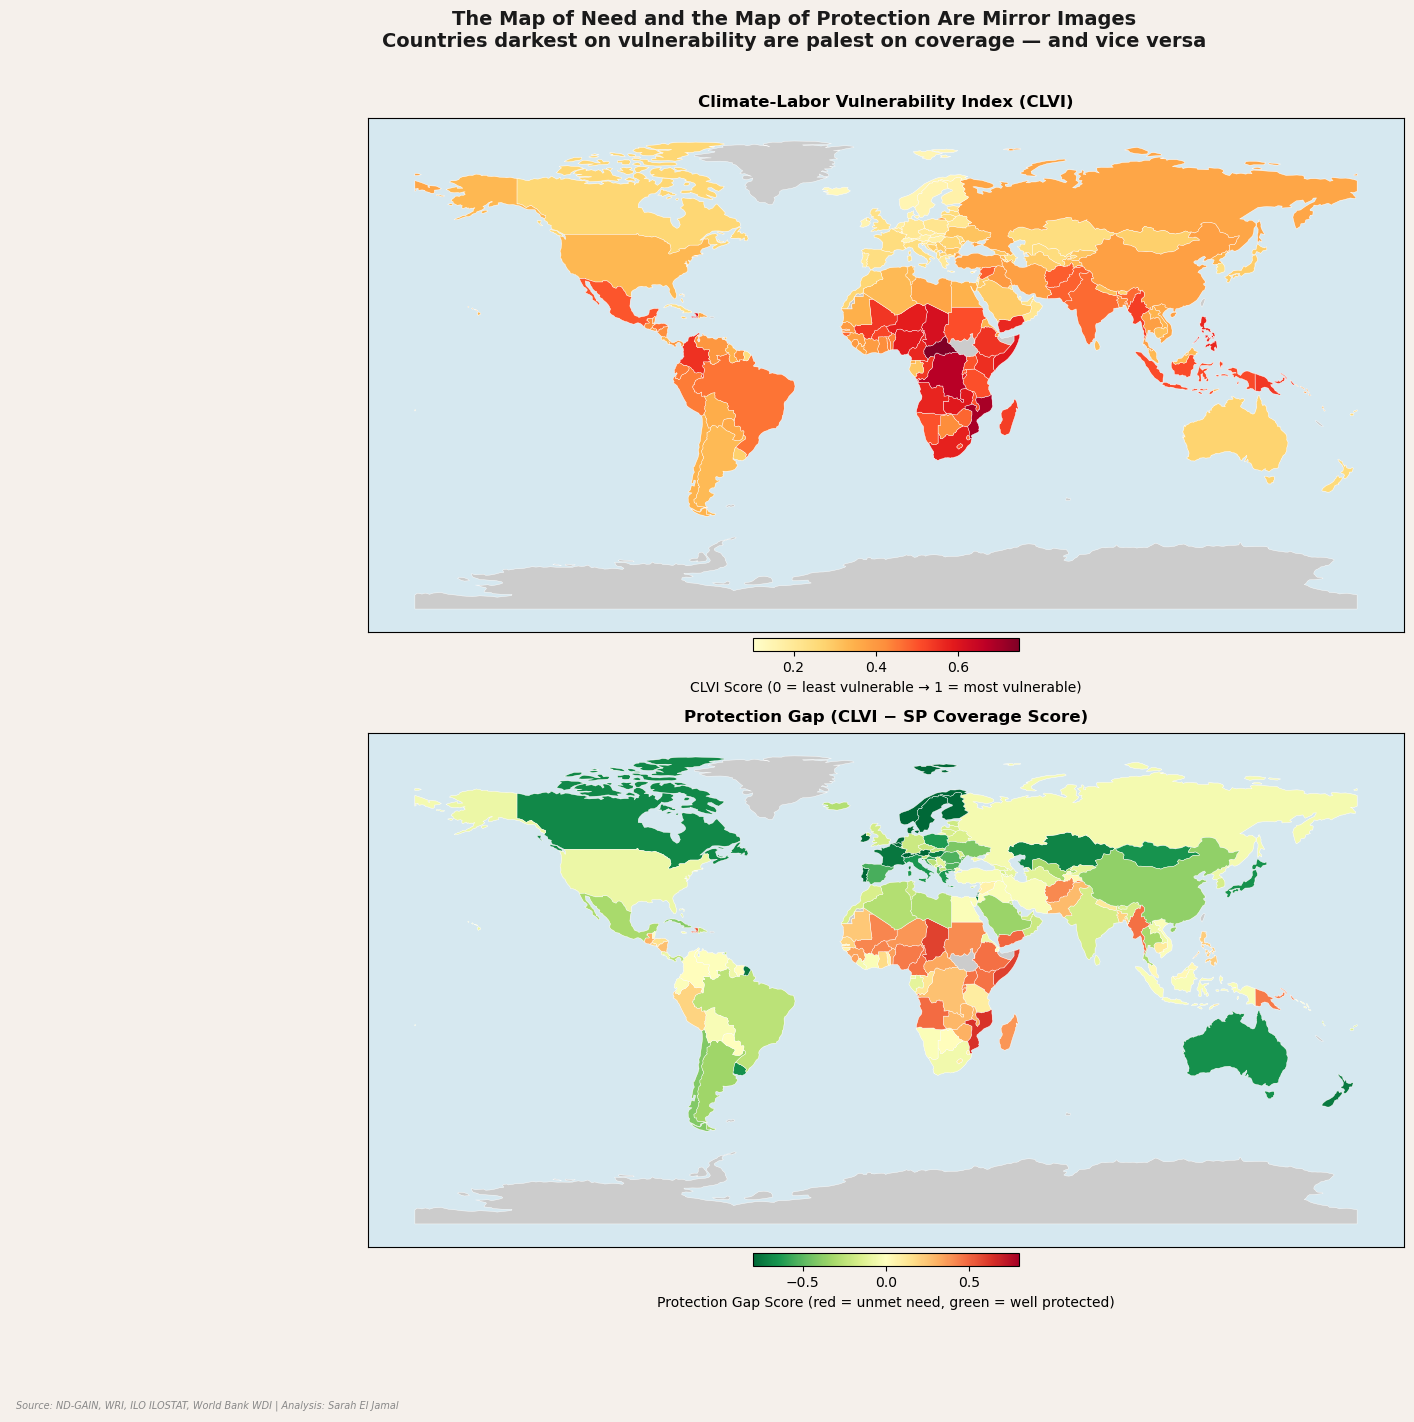

✓ Map 6 saved


In [30]:
fig, axes = plt.subplots(2, 1, figsize=(16, 14))
fig.patch.set_facecolor(BACKGROUND)

for ax in axes:
    ax.set_facecolor(OCEAN)
    ax.set_xticks([])
    ax.set_yticks([])

# ── Top: CLVI ─────────────────────────────────────────────────────────────────
gdf.plot(ax=axes[0], color=NO_DATA, edgecolor=BORDER, linewidth=0.3)
gdf[gdf['clvi'].notna()].plot(
    column='clvi', ax=axes[0],
    cmap='YlOrRd', vmin=0.1, vmax=0.75,
    edgecolor=BORDER, linewidth=0.3,
    legend=True,
    legend_kwds={
        'label': 'CLVI Score (0 = least vulnerable → 1 = most vulnerable)',
        'orientation': 'horizontal', 'fraction': 0.025, 'pad': 0.01, 'shrink': 0.5
    }
)
axes[0].set_title('Climate-Labor Vulnerability Index (CLVI)', fontsize=12, fontweight='bold', pad=8)

# ── Bottom: Protection Gap ─────────────────────────────────────────────────────
gdf.plot(ax=axes[1], color=NO_DATA, edgecolor=BORDER, linewidth=0.3)
gdf[gdf['protection_gap'].notna()].plot(
    column='protection_gap', ax=axes[1],
    cmap='RdYlGn_r', vmin=-0.8, vmax=0.8,
    edgecolor=BORDER, linewidth=0.3,
    legend=True,
    legend_kwds={
        'label': 'Protection Gap Score (red = unmet need, green = well protected)',
        'orientation': 'horizontal', 'fraction': 0.025, 'pad': 0.01, 'shrink': 0.5
    }
)
axes[1].set_title('Protection Gap (CLVI − SP Coverage Score)', fontsize=12, fontweight='bold', pad=8)

fig.suptitle(
    'The Map of Need and the Map of Protection Are Mirror Images\n'
    'Countries darkest on vulnerability are palest on coverage — and vice versa',
    fontsize=14, fontweight='bold', color='#1a1a1a', y=1.01
)

add_source(axes[1])
plt.tight_layout()
plt.savefig('outputs/geopandas/map6_sidebyside_geopandas.png', dpi=150, bbox_inches='tight', facecolor=BACKGROUND)
plt.show()
print('✓ Map 6 saved')

---
## 9. Summary

All maps saved to `outputs/geopandas/`:

| File | Description |
|---|---|
| `map1_clvi_geopandas.png` | CLVI world choropleth with case study annotations |
| `map2_protection_gap_geopandas.png` | Protection gap — diverging red/green scale |
| `map3_sp_coverage_geopandas.png` | SP coverage rate by country |
| `map4_invisibility_geopandas.png` | H5 — invisible countries coloured by CLVI |
| `map5_redzone_geopandas.png` | Red Zone countries coloured by protection gap |
| `map6_sidebyside_geopandas.png` | CLVI and protection gap as two-panel figure |

---

